# Modern Deep Convolutional Neural Networks with PyTorch
## Boat-Type Classification with Transfer Learning

This notebook follows the boat-recognition screenshots: prepare the nine-class Kaggle boat dataset, visualize augmented images, replace a pretrained ResNet-18 classifier head, freeze the backbone, train, and evaluate accuracy.

It is separate from `1.MLP.ipynb` and `2.CIFAR10_ConvNet.ipynb`. Boat files use `./data/boats` so they do not overlap the existing CIFAR-10 cache. Loading pretrained ResNet-18 weights may download a checkpoint if it is not already cached.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, ResNet152_Weights, resnet18
from torchvision.utils import make_grid

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
torch.manual_seed(42)
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.13.0 | device: mps


## 1. Prepare the boat dataset

The screenshots use the public `clorichel/boat-types-recognition` Kaggle dataset. The command below downloads and extracts it into a boat-specific folder; it is documentation only and is not run automatically. Kaggle CLI credentials are required.

```bash
kaggle datasets download -d clorichel/boat-types-recognition -p ./data/boats --unzip
```

`ImageFolder` expects one directory per class directly inside `./data/boats`. The screenshots show 1,476 images across nine classes.

In [6]:
data_root = Path("./data/boats")
batch_size = 16
num_workers = 0
n_epochs = 5

if data_root.is_dir():
    print(f"Boat dataset directory found: {data_root}")
else:
    print(f"Boat dataset not found yet; download it to {data_root}")

print(f"Training device: {device}")

Boat dataset directory found: data/boats
Training device: mps


## 2. Preprocessing and augmentation

The screenshots demonstrate resizing, random rotation, horizontal and vertical flips, and grayscale conversion. These random augmentations are applied only to training images; test preprocessing stays deterministic. Because the classifier starts from ImageNet weights, both splits use the normalization and evaluation transform associated with those weights.

In [7]:
weights = ResNet18_Weights.DEFAULT
weight_preprocess = weights.transforms()
imagenet_mean = weight_preprocess.mean
imagenet_std = weight_preprocess.std

eval_transform = weight_preprocess
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=(-30, 30)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print(f"ImageNet mean: {imagenet_mean}")
print(f"ImageNet standard deviation: {imagenet_std}")

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet standard deviation: [0.229, 0.224, 0.225]


## 3. Split the data and create loaders

The screenshots use a 70/30 split and batches of 16. A fixed seed makes the split reproducible. Separate `ImageFolder` instances share the same class ordering while allowing augmented training images and deterministic test images. `num_workers=0` avoids multiprocessing surprises in local macOS notebooks; increase it to 2 if your environment supports notebook workers.

In [8]:
if not data_root.is_dir():
    raise FileNotFoundError(
        f"Boat images are missing from {data_root}. Run the Kaggle command in section 1 first."
    )

base_dataset = datasets.ImageFolder(root=str(data_root))
classes = base_dataset.classes
if len(classes) != 9:
    raise ValueError(f"Expected 9 boat classes, found {len(classes)}: {classes}")

train_size = int(0.7 * len(base_dataset))
test_size = len(base_dataset) - train_size
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(base_dataset), generator=generator).tolist()
train_indices = indices[:train_size]
test_indices = indices[train_size:]

train_base = datasets.ImageFolder(root=str(data_root), transform=train_transform)
test_base = datasets.ImageFolder(root=str(data_root), transform=eval_transform)
assert train_base.classes == test_base.classes == classes

train_dataset = Subset(train_base, train_indices)
test_dataset = Subset(test_base, test_indices)
trainloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)
testloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print(f"Images: {len(base_dataset):,}")
print(f"Training images: {len(train_dataset):,}")
print(f"Test images: {len(test_dataset):,}")
print(f"Classes: {classes}")

Images: 1,462
Training images: 1,023
Test images: 439
Classes: ['buoy', 'cruise ship', 'ferry boat', 'freight boat', 'gondola', 'inflatable boat', 'kayak', 'paper boat', 'sailboat']


### Preview a training batch

The images below have already passed through the random training transforms. The display helper reverses ImageNet normalization before plotting.

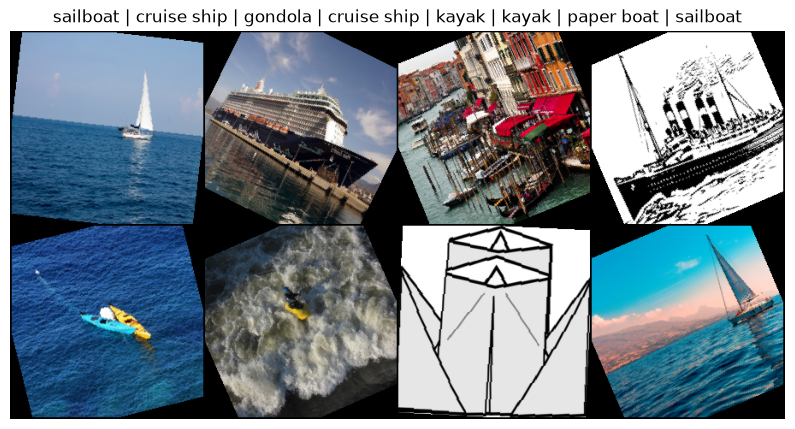

In [9]:
def show_images(images, labels, class_names, nrow=4):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    images = images.detach().cpu() * std + mean
    images = images.clamp(0, 1)
    grid = make_grid(images, nrow=nrow)

    plt.figure(figsize=(10, 6))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(" | ".join(class_names[int(label)] for label in labels))
    plt.show()


images, labels = next(iter(trainloader))
show_images(images[:8], labels[:8], classes)

## 4. Transfer learning with ResNet

The screenshots briefly inspect ResNet-152, then use ResNet-18 for the boat classifier. The optional inspection below is commented out because it downloads a larger checkpoint; the training path uses only ResNet-18.

In [10]:
# Optional architecture inspection from the screenshots. This downloads weights if uncached.
# from torchvision.models import resnet152
# exploratory_resnet152 = resnet152(weights=ResNet152_Weights.DEFAULT)
# print(exploratory_resnet152)

In [11]:
net = resnet18(weights=weights)

for parameter in net.parameters():
    parameter.requires_grad = False

net.fc = nn.Linear(net.fc.in_features, len(classes))
net = net.to(device)

assert net.fc.in_features == 512
assert net.fc.out_features == 9
trainable_parameters = sum(
    parameter.numel() for parameter in net.parameters() if parameter.requires_grad
)
print(net.fc)
print(f"Trainable parameters: {trainable_parameters:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/ankit/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Linear(in_features=512, out_features=9, bias=True)
Trainable parameters: 4,617


## 5. Configure training and evaluate accuracy

Only the new fully connected layer is trainable. The accuracy helper switches to evaluation mode and disables gradients, then restores the model's prior mode. Test batches are kept in a fixed order.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.fc.parameters(), lr=0.01)

In [13]:
def get_quality(model, dataloader):
    was_training = model.training
    model.eval()
    correct = 0
    total = 0

    try:
        with torch.inference_mode():
            for images, labels in dataloader:
                images = images.to(device)
                labels = labels.to(device)
                predictions = model(images).argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
    finally:
        model.train(was_training)

    if total == 0:
        raise ValueError("Cannot evaluate accuracy on an empty data loader")

    accuracy = 100.0 * correct / total
    print(f"Accuracy on {total:,} test images: {accuracy:.1f}%")
    return accuracy

In [14]:
def train_network(model, train_loader, test_loader, loss_fn, optimizer, n_epochs=5):
    history = {
        "batch_loss": [],
        "epoch_loss": [],
        "test_accuracy": [],
    }

    for epoch in range(n_epochs):
        model.train()
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        running_loss = 0.0
        batch_count = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_loss = loss.item()
            history["batch_loss"].append(batch_loss)
            running_loss += batch_loss
            batch_count += 1

        if batch_count == 0:
            raise ValueError("Cannot train on an empty data loader")

        epoch_loss = running_loss / batch_count
        history["epoch_loss"].append(epoch_loss)
        accuracy = get_quality(model, test_loader)
        history["test_accuracy"].append(accuracy)
        print(
            f"Epoch {epoch + 1}/{n_epochs} - "
            f"mean loss: {epoch_loss:.3f} - test accuracy: {accuracy:.1f}%"
        )

    model.eval()
    return history

### Train the classifier

The screenshots train for five epochs and evaluate test accuracy after each epoch. Run this cell only after completing the dataset and model setup above.

In [15]:
history = train_network(
    net,
    trainloader,
    testloader,
    criterion,
    optimizer,
    n_epochs=n_epochs,
)

Accuracy on 439 test images: 79.5%
Epoch 1/5 - mean loss: 1.702 - test accuracy: 79.5%
Accuracy on 439 test images: 78.4%
Epoch 2/5 - mean loss: 0.826 - test accuracy: 78.4%
Accuracy on 439 test images: 82.5%
Epoch 3/5 - mean loss: 0.744 - test accuracy: 82.5%
Accuracy on 439 test images: 77.7%
Epoch 4/5 - mean loss: 0.860 - test accuracy: 77.7%
Accuracy on 439 test images: 77.4%
Epoch 5/5 - mean loss: 0.707 - test accuracy: 77.4%


## 6. Training curves

The held-out accuracy can move between epochs on this relatively small dataset. Compare the trend rather than expecting the exact values shown in the recording.

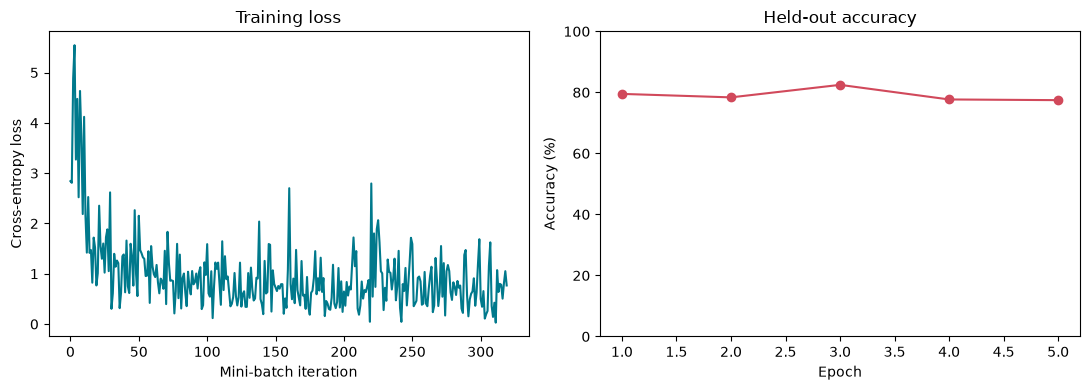

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["batch_loss"], color="#00798c")
axes[0].set(
    title="Training loss",
    xlabel="Mini-batch iteration",
    ylabel="Cross-entropy loss",
)

epoch_numbers = range(1, len(history["test_accuracy"]) + 1)
axes[1].plot(
    epoch_numbers,
    history["test_accuracy"],
    marker="o",
    color="#d1495b",
)
axes[1].set(
    title="Held-out accuracy",
    xlabel="Epoch",
    ylabel="Accuracy (%)",
    ylim=(0, 100),
)

plt.tight_layout()
plt.show()